In [54]:
import numpy as np
from sklearn.linear_model import LinearRegression

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.utils.data.dataset import random_split
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

## data generation

In [55]:
true_b = 1
true_w = 2
N = 100

# Data Generation
np.random.seed(42)
x = np.random.rand(N, 1)
y = true_b + true_w * x + (.1 * np.random.randn(N, 1))

# Shuffles the indices
idx = np.arange(N)
np.random.shuffle(idx)

# Uses first 80 random indices for train
train_idx = idx[:int(N*.8)]
# Uses the remaining indices for validation
val_idx = idx[int(N*.8):]

# Generates train and validation sets
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

## data preparation

In [56]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Our data was in Numpy arrays, but we need to transform them
# into PyTorch's Tensors and then we send them to the 
# chosen device
x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

## model config

In [57]:

# This is redundant now, but it won't be when we introduce
# Datasets...
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sets learning rate - this is "eta" ~ the "n"-like Greek letter
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# Defines a SGD optimizer to update the parameters 
# (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

In [58]:
n_epochs = 1000
for epoch in range(n_epochs):
    model.train()
    yhat = model(x_train_tensor)
    loss = loss_fn(yhat, y_train_tensor)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [59]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9690]])), ('0.bias', tensor([1.0235]))])


In [60]:
def make_train_step(model, loss_fn, optimizer):
    def perfrom_train_step_fn(x, y):
        model.train()
        yhat = model(x)
        loss = loss_fn(yhat, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        return loss.item()
    return perfrom_train_step_fn

In [61]:

# This is redundant now, but it won't be when we introduce
# Datasets...
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sets learning rate - this is "eta" ~ the "n"-like Greek letter
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# Defines a SGD optimizer to update the parameters 
# (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

# create the train_step function for our model, loss function and optimizer
train_step_fn = make_train_step(model, loss_fn, optimizer)

In [62]:
train_step_fn

<function __main__.make_train_step.<locals>.perfrom_train_step_fn(x, y)>

In [63]:
n_epochs = 1000
losses = []

for epoch in range(n_epochs):
    loss = train_step_fn(x_train_tensor, y_train_tensor)
    losses.append(loss)

In [64]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9690]])), ('0.bias', tensor([1.0235]))])


# Dataset

In [65]:
class CustomDataset(Dataset):
    def __init__(self, x_tensor, y_tensor):
        self.x = x_tensor
        self.y = y_tensor

    def __getitem__(self, index):
        return (self.x[index], self.y[index])

    def __len__(self):
        return len(self.x)

x_train_tensor = torch.as_tensor(x_train).float()
y_train_tensor = torch.as_tensor(y_train).float()

train_data = CustomDataset(x_train_tensor, y_train_tensor)
print(train_data[0])

(tensor([0.7713]), tensor([2.4745]))


## TensorDataset

In [66]:
train_data = TensorDataset(x_train_tensor, y_train_tensor)
print(train_data[0])

(tensor([0.7713]), tensor([2.4745]))


# DataLoader

In [67]:
train_loader = DataLoader(
    dataset=train_data,
    batch_size=16,
    shuffle=True,
)

In [68]:
next(iter(train_loader))

[tensor([[0.2809],
         [0.3253],
         [0.1560],
         [0.5924],
         [0.0651],
         [0.8872],
         [0.4938],
         [0.0055],
         [0.1409],
         [0.0885],
         [0.1849],
         [0.7290],
         [0.8662],
         [0.3117],
         [0.6842],
         [0.1987]]),
 tensor([[1.5846],
         [1.8057],
         [1.2901],
         [2.1687],
         [1.1559],
         [2.8708],
         [1.9060],
         [1.0632],
         [1.1211],
         [1.0708],
         [1.5888],
         [2.4927],
         [2.6805],
         [1.7637],
         [2.3492],
         [1.2654]])]

In [69]:
import os
os.makedirs("data_preparation", exist_ok=True)

In [70]:
%%writefile data_preparation/v1.py

x_train_tensor = torch.as_tensor(x_train).float()
y_train_tensor = torch.as_tensor(y_train).float()

train_data = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(
    dataset=train_data,
    batch_size=16,
    shuffle=True
)

Overwriting data_preparation/v1.py


In [71]:
%run -i data_preparation/v1.py

In [72]:
os.makedirs('model_configuration', exist_ok=True)

In [73]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [74]:
%%writefile model_configuration/v2.py
n_epochs = 1000

losses = []

for epoch in range(n_epochs):
    mini_batch_losses = []
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        mini_batch_loss = train_step_fn(x_batch, y_batch)
        mini_batch_losses.append(mini_batch_loss)
    loss = np.mean(mini_batch_losses)
    losses.append(loss)

Overwriting model_configuration/v2.py


In [75]:
%run -i model_configuration/v2.py

In [76]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9698]])), ('0.bias', tensor([1.0246]))])


## Mini-Batch Inner Loop

In [77]:
def mini_batch(device, data_loader, step_fn):
    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        mini_batch_loss = step_fn(x_batch, y_batch)
        mini_batch_losses.append(mini_batch_loss)
    loss = np.mean(mini_batch_losses)
    return loss

In [78]:
os.makedirs('model_training', exist_ok=True)

In [79]:
%%writefile model_training/v3.py
n_epochs = 200
losses = []

for epoch in range(n_epochs):
    loss = mini_batch(device, train_loader, train_step_fn)
    losses.append(loss)

Overwriting model_training/v3.py


In [80]:
%run -i model_training/v3.py

In [81]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9682]])), ('0.bias', tensor([1.0231]))])


In [82]:
%%writefile data_preparation/v2.py
torch.manual_seed(42)

x_tensor = torch.as_tensor(x).float()
y_tensor = torch.as_tensor(y).float()

dataset = TensorDataset(x_tensor, y_tensor)

# perfroms the split
ratio = .8
n_total = len(dataset)
n_train = int(n_total * ratio)
n_val = n_total - n_train
train_data, val_data = random_split(dataset, [n_train, n_val])

# buils a loader of each set
train_loader = DataLoader(
    dataset=train_data,
    batch_size=16,
    shuffle=True
)
val_loader = DataLoader(dataset=val_data, batch_size=16)

Overwriting data_preparation/v2.py


In [83]:
run -i data_preparation/v2.py

# Evalution

In [84]:
def make_val_step_fn(model, loss_fn):
    def perfrom_val_step_fn(x, y):
        # sets model to eval mode
        model.eval()
        yhat = model(x)
        loss = loss_fn(yhat, y)
        return loss.item()
    return perfrom_val_step_fn

In [85]:
%%writefile model_configuration/v2.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr = 0.1
torch.manual_seed(42)

model = nn.Sequential(nn.Linear(1, 1)).to(device)
optimizer = optim.SGD(model.parameters(), lr=lr)
loss_fn = nn.MSELoss(reduction='mean')
train_step_fn = make_train_step(model, loss_fn, optimizer)
val_step_fn = make_val_step_fn(model, loss_fn)

Overwriting model_configuration/v2.py


In [86]:
%run -i model_configuration/v2.py

In [87]:
%%writefile model_training/v4.py
n_epochs = 200

losses = []
val_losses = []

for epoch in range(n_epochs):
    # inner loop
    loss = mini_batch(device, train_loader, train_step_fn)
    losses.append(loss)

    # validation - no gradients in validation
    with torch.no_grad():
        val_loss = mini_batch(device, val_loader, val_step_fn)
        val_losses.append(val_loss)

Overwriting model_training/v4.py


In [88]:
%run -i model_training/v4.py

In [89]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9599]])), ('0.bias', tensor([1.0151]))])


# TensorBoard

In [90]:
# load the TensorBoard notebook extention
%load_ext tensorboard

In [91]:
%tensorboard --logdir runs

## summaryWriter

In [92]:
writer = SummaryWriter('runs/test')

## add_graph

In [93]:
dummy_x, dummy_y = next(iter(train_loader))
writer.add_graph(model, dummy_x.to(device))

In [94]:
%tensorboard --logdir runs

Reusing TensorBoard on port 6006 (pid 20326), started 0:00:00 ago. (Use '!kill 20326' to kill it.)

## add_scalars

In [95]:
writer.add_scalars(
    main_tag='loss',
    tag_scalar_dict={'training': loss.item(),
                    'validation': val_loss.item()},
    global_step=epoch
)
writer.flush()

In [96]:
%tensorboard --logdir runs/test

In [97]:
%run -i data_preparation/v2.py

In [98]:
%%writefile model_configuration/v3.py
device = 'cuda' if torch.cuda.is_available() else 'cpu'
lr = 0.1
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(1, 1)).to(device)
optimizer = optim.SGD(model.parameters(), lr=lr)
loss_fn = nn.MSELoss(reduction='mean')
train_step_fn = make_train_step(model, loss_fn, optimizer)
val_step_fn = make_val_step_fn(model, loss_fn)
writer = SummaryWriter('runs/simple_linear_regression')
x_dummy, y_dummy = next(iter(train_loader))
writer.add_graph(model, dummy_x.to(device))

Overwriting model_configuration/v3.py


In [99]:
%run -i model_configuration/v3.py

In [100]:
%%writefile model_training/v5.py
n_epochs = 200
losses = []
val_losses = []

for epoch in range(n_epochs):
    loss = mini_batch(device, train_loader, train_step_fn)
    losses.append(loss)

    # validation - no gradients in validation
    with torch.no_grad():
        val_loss = mini_batch(device, val_loader, val_step_fn)
        val_losses.append(val_loss)

    writer.add_scalars(main_tag='loss',
                    tag_scalar_dict={
                        'training': loss,
                        'validation': val_loss
                    },
                    global_step=epoch)
writer.close()

Overwriting model_training/v5.py


In [101]:
%run -i model_training/v5.py

In [102]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9583]])), ('0.bias', tensor([1.0099]))])


In [103]:
%tensorboard --logdir runs

Reusing TensorBoard on port 6006 (pid 20326), started 0:00:02 ago. (Use '!kill 20326' to kill it.)

# Saving and Loading Models

## saving

In [104]:
checkpoint = {'epoch': n_epochs,
              'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimizer.state_dict(),
              'loss': losses,
              'val_loss': val_losses}
torch.save(checkpoint, 'model_checkpoint.pth')

## Resuming Training

In [105]:
%run -i data_preparation/v2.py
%run -i model_configuration/v3.py

In [106]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[0.7645]])), ('0.bias', tensor([0.8300]))])


In [107]:
checkpoint = torch.load('model_checkpoint.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

saved_epoch = checkpoint['epoch']
saved_losses = checkpoint['loss']
saved_val_losses = checkpoint['val_loss']

model.train()

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
)

In [108]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9583]])), ('0.bias', tensor([1.0099]))])


In [109]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9583]])), ('0.bias', tensor([1.0099]))])


In [110]:
%run -i model_configuration/v3.py

In [111]:
checkpoint = torch.load('model_checkpoint.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9583]])), ('0.bias', tensor([1.0099]))])


In [112]:
new_inputs = torch.tensor([[.20], [.34], [.57]])
model.eval()
model(new_inputs.to(device))

tensor([[1.4015],
        [1.6757],
        [2.1261]], grad_fn=<AddmmBackward0>)

# Chapter 2.1

In [113]:
import numpy as np
import datetime

import torch
import torch.optim as optim
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

## Going Classy

In [114]:
class StepByStep(object):
    pass

In [115]:
class StepByStep(object):
    def __init__(self, model, loss_fn, optimizer):
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model.to(self.device)
        self.train_loader = None
        self.val_loader = None
        self.writer = None
        self.losses = []
        self.val_losses = []
        self.total_epochs = 0
        self.train_step_fn = self._make_train_step_fn()
        self.val_step_fn = self._make_val_step_fn()

    def to(self, device):
        try:
            self.device = device
            self.model.to(device)
        except RuntimeError:
            self.device = ('cuda' if torch.cuda.is_available() else 'cpu')
            print(f"Couldn't send it to {device}, sending it to {self.device} instead")
            self.model.to(self.device)

    def set_loaders(self, train_loader, val_loader=None):
        self.train_loader = train_loader
        self.val_loader = val_loader

    def set_tensorboard(self, name, folder='runs'):
        suffix = datetime.datetime.now().strftime('%Y%m%d%H%M%S')
        self.writer = SummaryWriter(f'{folder}/{name}_{suffix}')

In [116]:
def _make_train_step_fn(self):
    def perform_train_step_fn(x, y):
        self.model.train()
        yhat = self.model(x)
        loss = self.loss_fn(yhat, y)
        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()
        return loss.item()
    return perform_train_step_fn

def _make_val_step_fn(self):
    def perform_val_step_fn(x, y):
        self.model.eval()
        yhat = self.model(x)
        loss = self.loss_fn(yhat, y)
        return loss.item()
    return perform_val_step_fn

In [117]:
setattr(StepByStep, '_make_train_step_fn', _make_train_step_fn)
setattr(StepByStep, '_make_val_step_fn', _make_val_step_fn)

In [118]:
class Dog(object):
    def __init__(self, name):
        self.name = name

In [119]:
rex = Dog('Rex')
print(rex.name)

Rex


In [120]:
def bark(dog):
    print('{} barks: "Woof!"'.format(dog.name))

In [121]:
bark(rex)

Rex barks: "Woof!"


In [122]:
def bark_2(self):
    print('{} barks: "Woof!"'.format(self.name))

setattr(Dog, 'bark_2', bark_2)

In [123]:
fido = Dog('fido')
fido.bark_2()

fido barks: "Woof!"


In [124]:
rex.bark_2()

Rex barks: "Woof!"


### training models

In [125]:
def _mini_batch(self, validation=False):
    if validation:
        data_loader = self.val_loader
        step_fn = self.val_step_fn
    else:
        data_loader = self.train_loader
        step_fn = self.train_step_fn
    if data_loader is None:
        return None

    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        mini_batch_loss = step_fn(x_batch, y_batch)
        mini_batch_losses.append(mini_batch_loss)

    loss = np.mean(mini_batch_losses)
    return loss

setattr(StepByStep, '_mini_batch', _mini_batch)

In [126]:
def set_seed(self, seed=42):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    np.random.seed(seed)

setattr(StepByStep, 'set_seed', set_seed)

In [127]:
def train(self, n_epochs, seed=42):
    self.set_seed(seed)

    for epoch in range(n_epochs):
        self.total_epochs += 1

        # training using mini_batch
        loss = self._mini_batch(validation=True)
        self.losses.append(loss)

        with torch.no_grad():
            val_loss = self._mini_batch(validation=True)
            self.val_losses.append(val_losses)

        if self.writer:
            scalars = {'training': loss}
            if val_loss is not None:
                scalars.update({'validation': val_loss})
            self.writer.add_scalars(main_tag='loss',
                                   tag_scalar_dict=scalars,
                                   global_step=epoch)
    if self.writer:
        self.writer.flush()

setattr(StepByStep, 'train', train)

In [128]:
# saving
def save_checkpoint(self, filname):
    checkpoint = {
        'epoch': self.total_epochs,
        'model_state_dict': self.model_state_dict(),
        'optimizer_state_dict': self.optimizer_state_dict(),
        'loss': self.losses,
        'val_loss': self.val_losses
    }
    toch.save(checkpoint, filname)

setattr(StepByStep, 'save_checkpoint', save_checkpoint)

In [129]:
# loading
def load_checkpoint(self, filename):
    checkpoint = torch.load(filename)
    self.model.load_state_dict(checkpoint['model_state_dict'])
    self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    self.total_epochs = checkpoint['epoch']
    self.losses = checkpoint['loss']
    self.val_losses = checkpoint['val_loss']
    self.model_train() # always use train for resuming training

setattr(StepByStep, 'load_checkpoint', load_checkpoint)

In [130]:
# making predictions
def predict(self, x):
    self.model.eval()
    x_tensor = torch.as_tensor(x).float()
    y_hat_tensor = self.model(x_tensor.to(device))
    self.model.train()
    return y_hat_tensor.detach().cpu().numpy()

setattr(StepByStep, 'predict', predict)

In [131]:
# visualization methods
def plot_losses(self):
    fig = plt.figure(figsize=(10, 4))
    plt.plot(self.losses, label='Training Loss', c='b')
    if self.val_loader:
        plt.plot(self.val_losses, label='Validation Loss', c='r')
    plt.yscale('log')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    return fig

setattr(StepByStep, 'plot_losses', plot_losses)

In [132]:
# model graph
def add_graph(self):
    if self.train_loader and self.writer:
        x_dummy, y_dummy = next(iter(self.train_loader))
        self.writer.add_graph(self.model, x_dummy.to(device))

setattr(StepByStep, 'add_graph', add_graph)

In [133]:
import os
os.makedirs('data_generation', exist_ok=True)

In [134]:
%%writefile data_generation/simple_linear_regression.py
import numpy as np

true_b = 1
true_w = 2
N = 100

# Data Generation
np.random.seed(42)
x = np.random.rand(N, 1)
y = true_b + true_w * x + (.1 * np.random.randn(N, 1))

# Shuffles the indices
idx = np.arange(N)
np.random.shuffle(idx)

# Uses first 80 random indices for train
train_idx = idx[:int(N*.8)]
# Uses the remaining indices for validation
val_idx = idx[int(N*.8):]

# Generates train and validation sets
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

Overwriting data_generation/simple_linear_regression.py


In [135]:
%run -i data_generation/simple_linear_regression.py

In [136]:
# run - data preparation v2
torch.manual_seed(13)

x_tensor = torch.as_tensor(x).float()
y_tensor = torch.as_tensor(y).float()

dataset = TensorDataset(x_tensor, y_tensor)

ratio = .8
n_total = len(dataset)
n_train = int(n_total * ratio)
n_val = n_total - n_train

train_data, val_data = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(
    dataset=train_data,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(dataset=val_data, batch_size=16)

In [137]:
%%writefile model_configuration/v4.py
lr = 0.1
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(1, 1))
optimizer = optim.SGD(model.parameters(), lr=lr)
loss_fn = nn.MSELoss(reduction='mean')

Overwriting model_configuration/v4.py


In [138]:
%run -i model_configuration/v4.py

In [139]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[0.7645]])), ('0.bias', tensor([0.8300]))])


In [140]:
sbs = StepByStep(model, loss_fn, optimizer)
sbs.set_loaders(train_loader, val_loader)
sbs.set_tensorboard('classy')

In [141]:
print(sbs.model == model)
print(sbs.model)

True
Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
)


In [142]:
sbs.train(n_epochs=200)

In [143]:
print(model.state_dict())
print(sbs.total_epochs)

OrderedDict([('0.weight', tensor([[0.7645]])), ('0.bias', tensor([0.8300]))])
200


/var/folders/8n/4tmx7gjx57j_gn5wps411qp40000gn/T/ipykernel_13501/2730629803.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


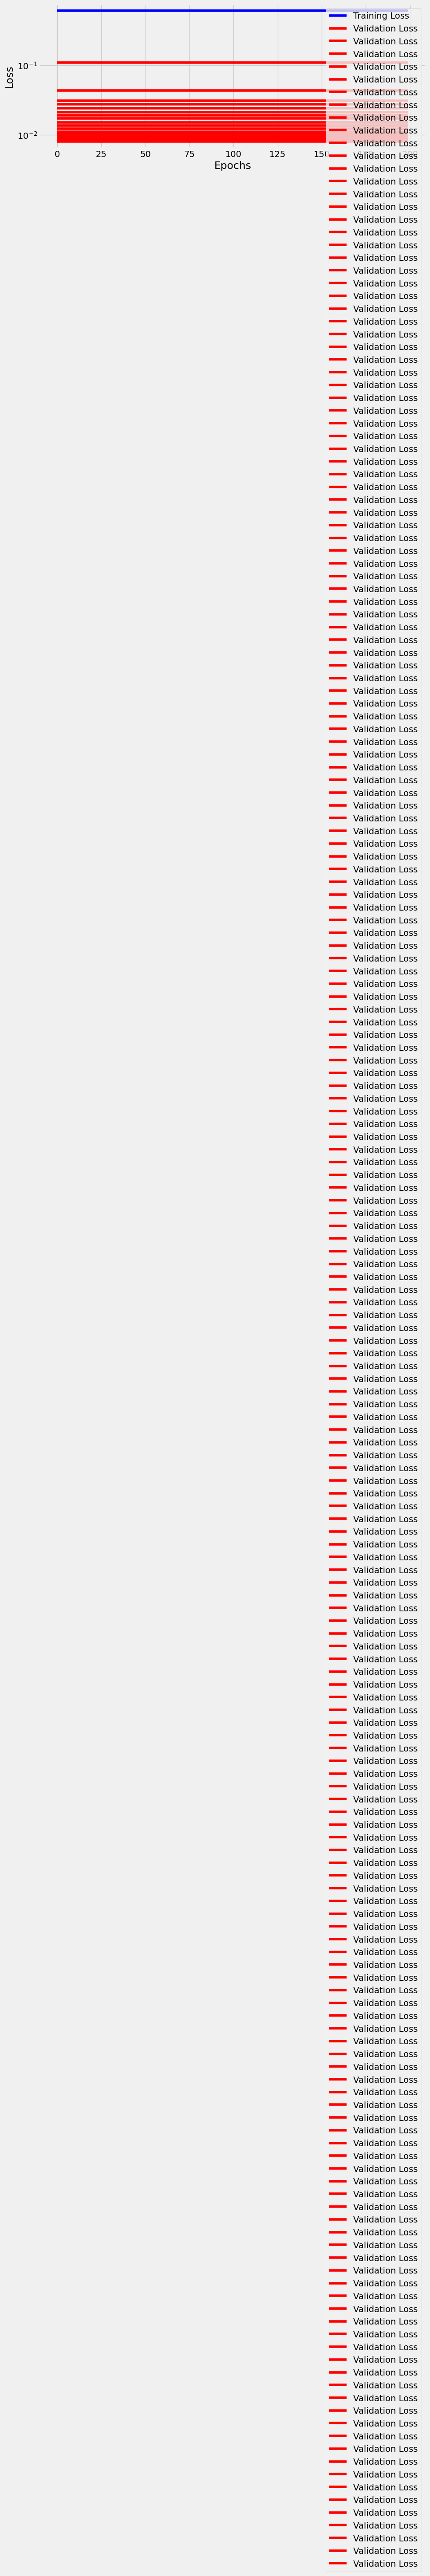

In [144]:
fig = sbs.plot_losses()